Hourly Energy Consumption of Pennsylvania-New Jersey-Maryland Interconnection (PJM) West Region
Using the PJM West Region: 2001-2018 (PJMW) estimated hourly energy consumption data from PJM in Megawatts: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption/data. Forecast the daily consumption one month in advance. Compare the MAE and MAPE accuracy of the best ARIMA, LSTM, GRU model. [10pts for each method]

In [1]:
import os

DATA_DIR = "data/"
fname = DATA_DIR + "PJMW_hourly.csv"
f = open(fname)
data = f.read()
f.close()
lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['Datetime', 'PJMW_MW']
143207


In [2]:
import pandas as pd

data2 = pd.read_csv(DATA_DIR + "PJMW_hourly.csv")
dummy = data2
dummy.head()

,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077.0
1,2002-12-31 02:00:00,4939.0
2,2002-12-31 03:00:00,4885.0
3,2002-12-31 04:00:00,4857.0
4,2002-12-31 05:00:00,4930.0


In [3]:
import numpy as np

float_data = np.zeros((len(lines), 1))

for i, line in enumerate(lines):
    # Split each line on the comma
    parts = line.split(",")

    # Check if the line has exactly two parts: Datetime and PJMW_MW
    if len(parts) != 2:
        print(f"Skipping line {i} due to unexpected format: {line}")
        continue

    try:
        # Extract and convert the PJMW_MW value to float
        value = float(parts[1].strip())
        float_data[i, 0] = value
    except ValueError as e:
        print(f"Skipping line {i} due to conversion error: {line}, Error: {e}")

print(float_data)

Skipping line 143206 due to unexpected format: 
[[5077.]
 [4939.]
 [4885.]
 ...
 [7958.]
 [7691.]
 [   0.]]


In [4]:
float_data.shape

(143207, 1)

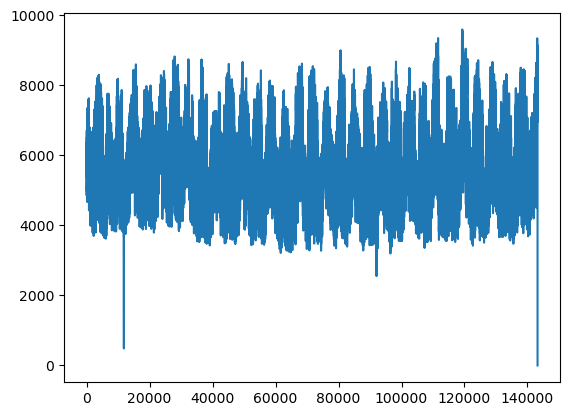

In [5]:
from matplotlib import pyplot as plt

%matplotlib inline

mw = float_data[:, 0]  # temperature (in degrees Celsius)
plt.plot(range(len(mw)), mw)

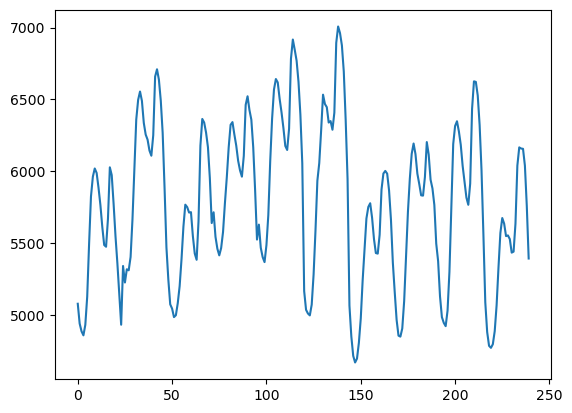

In [6]:
plt.plot(range(240), mw[:240])

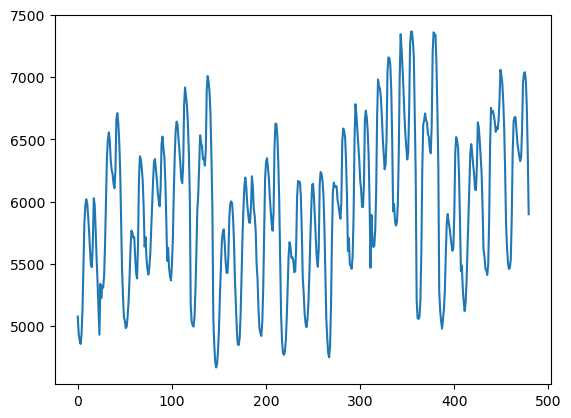

In [7]:
plt.plot(range(480), mw[:480])

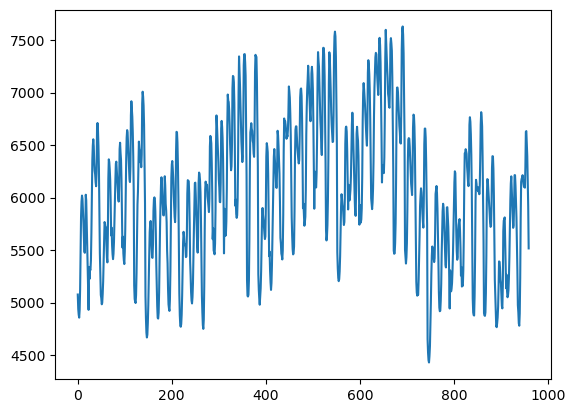

In [8]:
plt.plot(range(960), mw[:960])

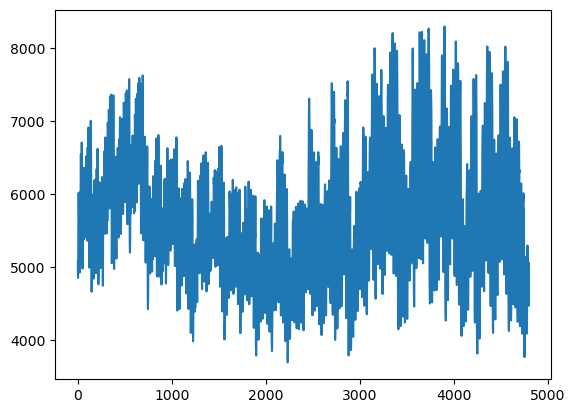

In [9]:
plt.plot(range(960 * 5), mw[: 960 * 5])

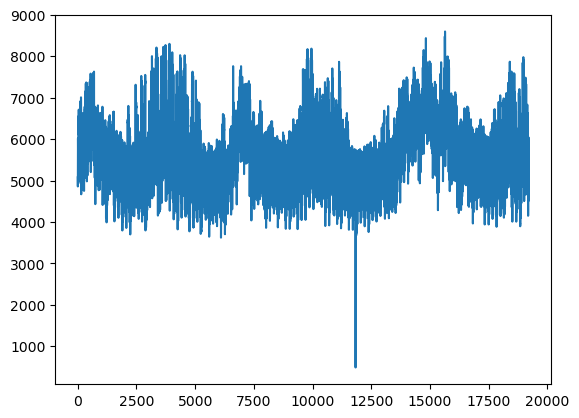

In [10]:
plt.plot(range(960 * 20), mw[: 960 * 20])

In [11]:
mean = float_data[:70000].mean(axis=0)
float_data -= mean  # ALL DATA BASED on theMEAN OF first 200k data points
std = float_data[:70000].std(axis=0)
float_data /= std  # ALL DATA BASED on the STD OF first 200k data points

In [12]:
std

array([947.68959387])

In [13]:
def generator(
    data,
    lookback,
    delay,
    min_index,
    max_index,
    shuffle=False,
    batch_size=128,
    step=12,
    num_outputs=1,
    target_i=0,
):
    # Set default max_index if not provided
    if max_index is None:
        max_index = len(data) - delay - 1

    # Start index for data sampling
    i = min_index + lookback

    # Infinite loop to generate samples indefinitely
    while True:
        # Shuffle data if required; otherwise, generate sequential batches
        if shuffle:
            rows = np.random.randint(min_index + lookback, max_index, size=batch_size)
        else:
            if i + batch_size >= max_index:
                i = min_index + lookback  # Reset index if it goes beyond the max index
            rows = np.arange(i, min(i + batch_size, max_index))
            i += len(rows)

        # Initialize numpy arrays to store samples and targets
        samples = np.zeros((len(rows), lookback // step, data.shape[-1]))
        targets = np.zeros((len(rows), num_outputs))

        # Populate samples and targets arrays
        for j, row in enumerate(rows):
            indices = range(rows[j] - lookback, rows[j], step)  # Select indices for sample
            samples[j] = data[indices]  # Assign the sliced data to samples

            # If the data has only one feature, adjust target indexing
            if data.shape[-1] == 1:
                targets[j] = data[rows[j] + delay : rows[j] + delay + num_outputs * step : step, 0]
            else:
                targets[j] = data[
                    rows[j] + delay : rows[j] + delay + num_outputs * step : step, target_i
                ]

        # Yield a batch of samples and targets
        yield samples, targets


# Example usage
lookback = 1 * 24 * 30  # 30-day look back in hours
step = 12  # Sampling every 12 hours
delay = 30 * 24  # 30 days into the future in hours
batch_size = 128

train_gen = generator(
    float_data,
    lookback=lookback,
    delay=delay,
    min_index=0,
    max_index=100000,
    shuffle=True,
    step=step,
    batch_size=batch_size,
    num_outputs=24,  # Number of future predictions
    target_i=0,  # Use 0 if data has only one feature
)

val_gen = generator(
    float_data,
    lookback=lookback,
    delay=delay,
    min_index=100001,
    max_index=121600,
    shuffle=False,
    step=step,
    batch_size=batch_size,
    num_outputs=24,
    target_i=0,
)

test_gen = generator(
    float_data,
    lookback=lookback,
    delay=delay,
    min_index=121601,
    max_index=None,
    step=step,
    batch_size=batch_size,
    num_outputs=24,
    target_i=0,
)

# Validation and test steps calculation
val_steps = (121600 - 100001 - lookback) // batch_size
test_steps = (len(float_data) - 121600 - lookback) // batch_size

In [14]:
import numpy as np


def evaluate_naive_method():
    # Initialize a list to store the mean absolute errors (MAEs) of each batch.
    batch_maes = []

    # Loop over a number of steps defined by val_steps.
    for step in range(val_steps):
        # Retrieve the next batch of data from the validation generator.
        samples, targets = next(val_gen)

        # Use the last reading from the last timestep in each sample as the prediction.
        # This assumes that your data format in samples is (batch_size, timesteps, features)
        preds = samples[:, -1, 0]  # Shape (128,)

        # Repeat the prediction for each of the future steps (24 steps in this example)
        repeated_preds = np.tile(preds[:, np.newaxis], (1, targets.shape[1]))

        # Calculate the mean absolute error (MAE) for the batch.
        mae = np.mean(np.abs(repeated_preds - targets))

        # Append the calculated MAE of the current batch to the list of batch MAEs.
        batch_maes.append(mae)

    # After processing all batches, compute the average of the MAEs to get a final performance metric.
    print("Average MAE: ", np.mean(batch_maes))


# Call the function to evaluate the naive method on your validation data.
evaluate_naive_method()

Average MAE:  1.088346846711845


In [15]:
std[0]

947.6895938678931

In [16]:
val_steps

163

In [17]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
from keras.callbacks import Callback


class LivePlot(Callback):
    def on_train_begin(self, logs={}):
        self.epoch = 0
        self.history = {"loss": [], "val_loss": []}

    def on_epoch_end(self, epoch, logs={}):
        self.history["loss"].append(logs.get("loss"))
        self.history["val_loss"].append(logs.get("val_loss"))
        self.epoch += 1

        # Clear the current output in the notebook
        clear_output(wait=True)
        # Plot the training and validation loss
        plt.figure(figsize=(10, 5))
        plt.plot(self.history["loss"], label="Training Loss")
        plt.plot(self.history["val_loss"], label="Validation Loss")
        plt.title("Training and Validation Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        plt.show()


# Create an instance of the live plot callback
live_plot = LivePlot()

## Feedforward NN


In [18]:
from keras import layers
from keras.layers import BatchNormalization, Dropout
from keras.models import Sequential
from tensorflow.keras.optimizers import RMSprop

model = Sequential()
model.add(layers.Flatten(input_shape=(lookback // step, float_data.shape[-1])))
model.add(layers.Dense(64, activation="relu"))
model.add(Dropout(0.5))
model.add(BatchNormalization())
model.add(layers.Dense(24))

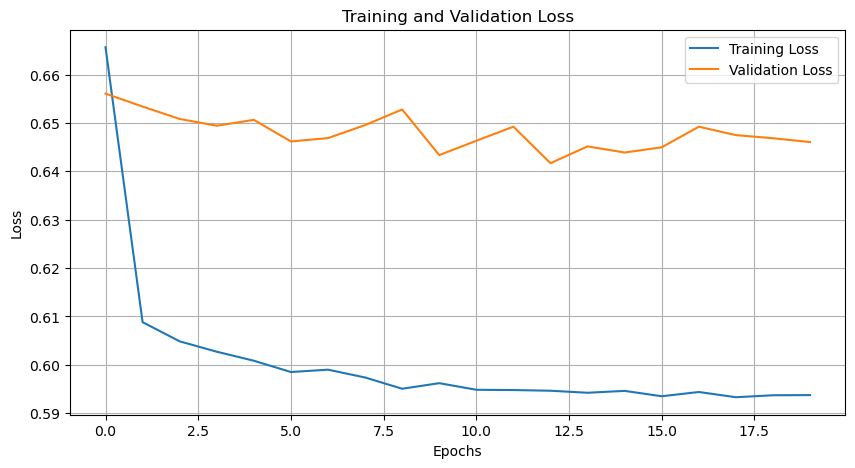

1000/1000 [==============================] - 7s 7ms/step - loss: 0.5937 - val_loss: 0.6461


In [19]:
model.compile(optimizer=RMSprop(learning_rate=0.001), loss="mae")
history = model.fit_generator(
    train_gen,
    steps_per_epoch=1000,  # ideally steps_per_epoch = TotalTrainingSamples / TrainingBatchSize
    epochs=20,
    validation_data=val_gen,
    validation_steps=2000,
    callbacks=[live_plot],
)  # ideally validation_steps = TotalvalidationSamples / ValidationBatchSize

## LSTM

In [20]:
from keras import layers
from keras.models import Sequential
from tensorflow.keras.optimizers import RMSprop

model = Sequential()
model.add(layers.LSTM(32, input_shape=(None, float_data.shape[-1])))
model.add(Dropout(0.5))
model.add(BatchNormalization())
model.add(layers.Dense(24))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 32)                4352      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 batch_normalization_1 (Bat  (None, 32)                128       
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 24)                792       
                                                                 
Total params: 5272 (20.59 KB)
Trainable params: 5208 (20.34 KB)
Non-trainable params: 64 (256.00 Byte)
_________________________________________________________________


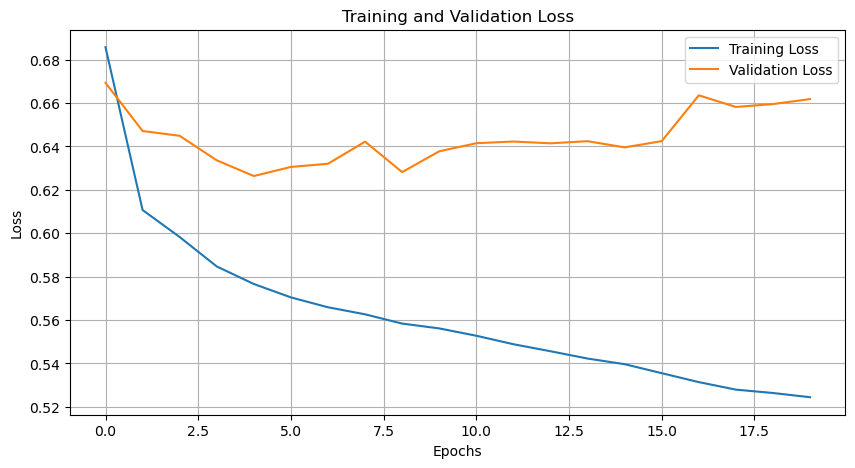

1000/1000 [==============================] - 18s 18ms/step - loss: 0.5245 - val_loss: 0.6618


In [21]:
model.compile(optimizer=RMSprop(learning_rate=0.001), loss="mae")
history = model.fit_generator(
    train_gen,
    steps_per_epoch=1000,
    epochs=20,
    validation_data=val_gen,
    validation_steps=2000,
    callbacks=[live_plot],
)

## GRU

In [22]:
from keras import layers
from keras.models import Sequential
from tensorflow.keras.optimizers import RMSprop

model = Sequential()
model.add(layers.GRU(32, input_shape=(None, float_data.shape[-1])))
model.add(Dropout(0.5))
model.add(BatchNormalization())
model.add(layers.Dense(24))

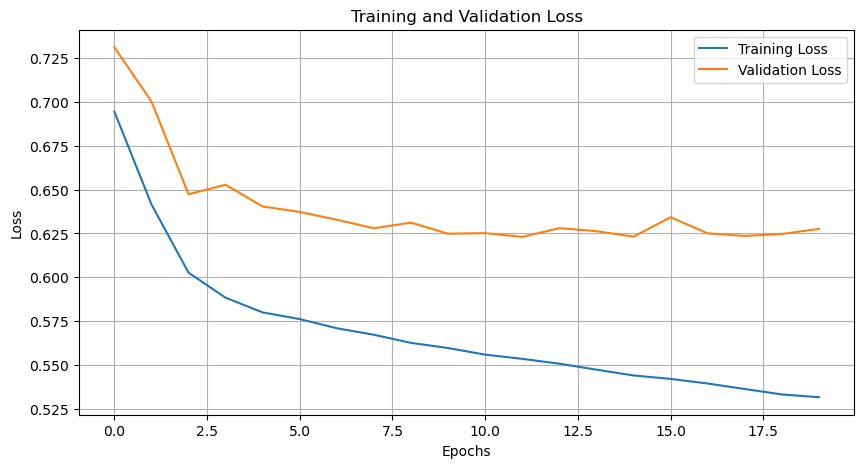

1000/1000 [==============================] - 17s 17ms/step - loss: 0.5315 - val_loss: 0.6276


In [23]:
model.compile(optimizer=RMSprop(learning_rate=0.001), loss="mae")
history = model.fit_generator(
    train_gen,
    steps_per_epoch=1000,
    epochs=20,
    validation_data=val_gen,
    validation_steps=2000,
    callbacks=[live_plot],
)

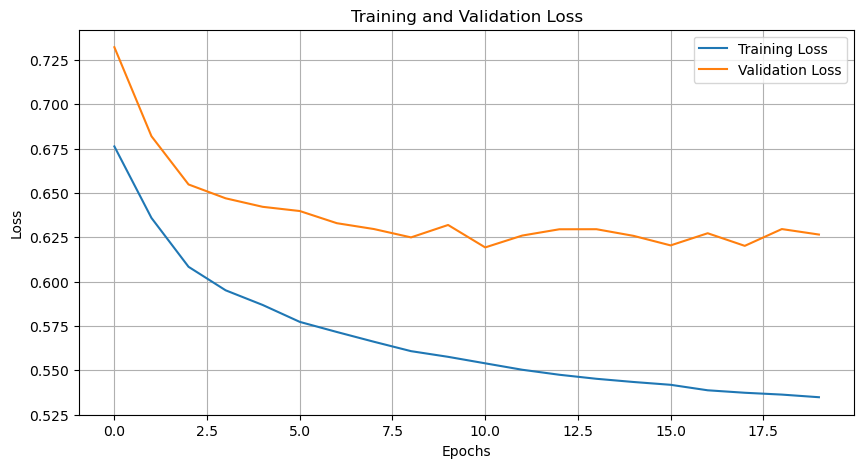

1000/1000 [==============================] - 26s 26ms/step - loss: 0.5348 - val_loss: 0.6265


In [24]:
# Training and evaluating a dropout-regularized GRU-based model

from keras import layers
from keras.models import Sequential

# from tensorflow.keras.optimizers import RMSprop

model = Sequential()
model.add(
    layers.GRU(32, dropout=0.2, recurrent_dropout=0.2, input_shape=(None, float_data.shape[-1]))
)
model.add(layers.Dense(24))

model.compile(optimizer=RMSprop(), loss="mae")
history = model.fit_generator(
    train_gen,
    steps_per_epoch=1000,
    epochs=20,
    validation_data=val_gen,
    validation_steps=2000,
    callbacks=[live_plot],
)

In [25]:
# Training and evaluating a dropout-regularized GRU-based model

from keras import layers
from keras.models import Sequential
from tensorflow.keras.optimizers import RMSprop

model = Sequential()
model.add(
    layers.GRU(32, dropout=0.2, recurrent_dropout=0.1, input_shape=(None, float_data.shape[-1]))
)
model.add(layers.Dense(24))

model.compile(optimizer=RMSprop(), loss="mae")

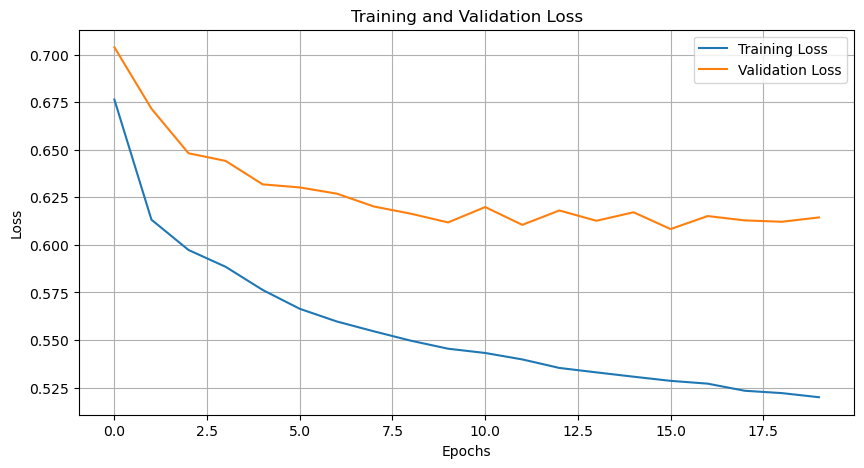

1000/1000 [==============================] - 25s 25ms/step - loss: 0.5199 - val_loss: 0.6145


In [26]:
history = model.fit_generator(
    train_gen,
    steps_per_epoch=1000,
    epochs=20,
    validation_data=val_gen,
    validation_steps=2000,
    callbacks=[live_plot],
)  # Pass the live plot callback)

## LSTM + GRU + LSTM

In [28]:
from tensorflow.keras import layers
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.models import Sequential

model = Sequential()

# First LSTM layer
model.add(layers.LSTM(32, input_shape=(None, float_data.shape[-1]), return_sequences=True))
model.add(Dropout(0.5))
model.add(BatchNormalization())

# GRU layer
model.add(layers.GRU(32, dropout=0.2, recurrent_dropout=0.2, return_sequences=True))

# Second LSTM layer
model.add(layers.LSTM(32))

# Final Dense layer
model.add(layers.Dense(24))

# Compile the model (as an example)
model.compile(optimizer="adam", loss="mse")

# Summary of the model
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, None, 32)          4352      
                                                                 
 dropout_3 (Dropout)         (None, None, 32)          0         
                                                                 
 batch_normalization_3 (Bat  (None, None, 32)          128       
 chNormalization)                                                
                                                                 
 gru_3 (GRU)                 (None, None, 32)          6336      
                                                                 
 lstm_2 (LSTM)               (None, 32)                8320      
                                                                 
 dense_6 (Dense)             (None, 24)                792       
                                                      

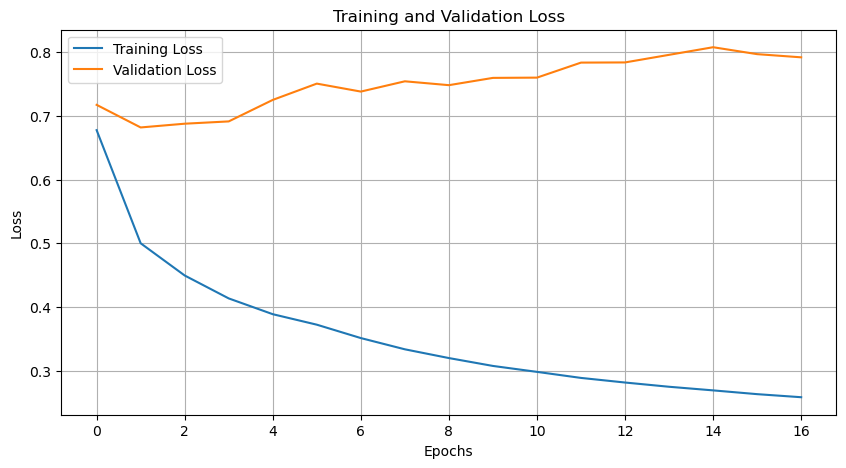

1000/1000 [==============================] - 77s 77ms/step - loss: 0.2581 - val_loss: 0.7920
Epoch 18/20
 171/1000 [====>.........................] - ETA: 46s - loss: 0.2532

KeyboardInterrupt: 

In [29]:
history = model.fit_generator(
    train_gen,
    steps_per_epoch=1000,
    epochs=20,
    validation_data=val_gen,
    validation_steps=2000,
    callbacks=[live_plot],
)  # Pass the live plot callback)

In [27]:
traing = []
for i in range(1000):
    traing.append(next(train_gen))

vg = []
for i in range(1000):
    vg.append(next(val_gen))

testg = []
for i in range(1000):
    testg.append(next(test_gen))

ValueError: could not broadcast input array from shape (23,) into shape (24,)

In [ ]:
vg_pred1 = model.predict(vg[0][0])  # predict first 1280 minutes or 21.33 hours
vg_pred2 = model.predict(vg[1][0])  # predict inputs of next 1280 mins
vg_pred3 = model.predict(vg[2][0])  # predict inputs of next 1280* 3
vg_pred4 = model.predict(vg[3][0])  # predict inputs of next 1280* 4
vg_pred5 = model.predict(vg[4][0])  # predict inputs of next 1280* 5
vg_pred6 = model.predict(vg[5][0])  # predict inputs of next 1280* 6
vg_pred10 = model.predict(vg[9][0])  # predict inputs of next 1280* 9
vg_pred1000 = model.predict(vg[999][0])  # predict inputs of next 1280* 1000

4/4 [==============================] - 0s 2ms/step


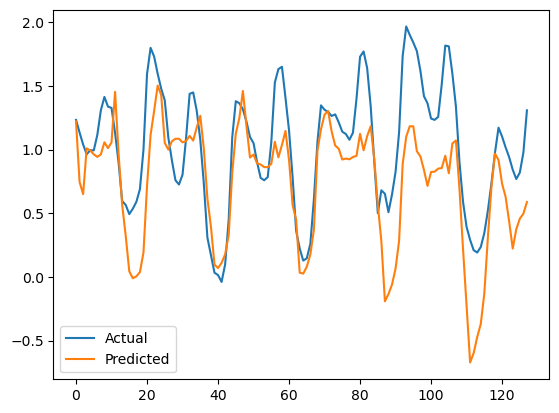

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(vg[1][1], label="Actual")
plt.plot(vg_pred2, label="Predicted")

plt.legend()
plt.show()

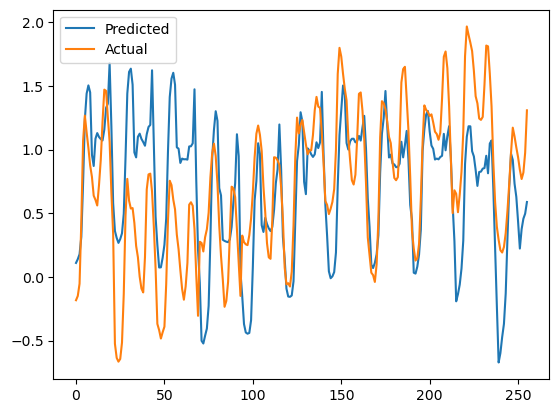

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.plot(np.append(vg_pred1, vg_pred2), label="Predicted")  # Corrected label
plt.plot(np.append(vg[0][1], vg[1][1]), label="Actual")  # Corrected label

plt.legend()
plt.show()

In [ ]:
batches_considered = 10

preds = np.array([])
targets = np.array([])
for v in vg[:batches_considered]:
    preds = np.append(preds, model.predict(v[0]))
    targets = np.append(targets, v[1])

4/4 [==============================] - 0s 2ms/step


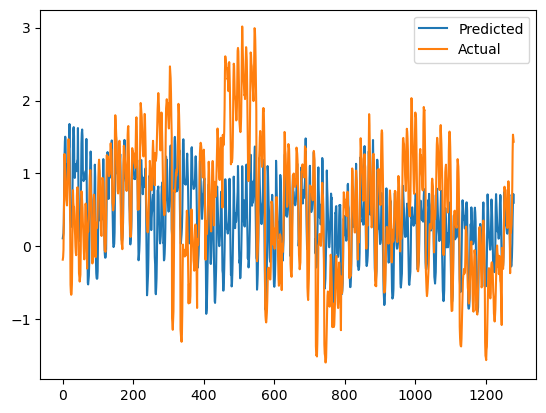

In [ ]:
plt.plot(preds, label="Predicted")
plt.plot(targets, label="Actual")

plt.legend()
plt.show()

In [ ]:
batches_considered = 20

preds_test = np.array([])
targets_test = np.array([])
for v in testg[:batches_considered]:
    preds_test = np.append(preds_test, model.predict(v[0]))
    targets_test = np.append(targets_test, v[1])

4/4 [==============================] - 0s 2ms/step


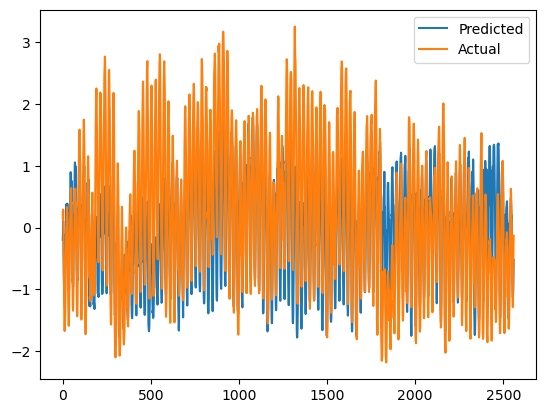

In [ ]:
plt.plot(preds_test, label="Predicted")
plt.plot(targets_test, label="Actual")
plt.legend()
plt.show()

4/4 [==============================] - 0s 2ms/step


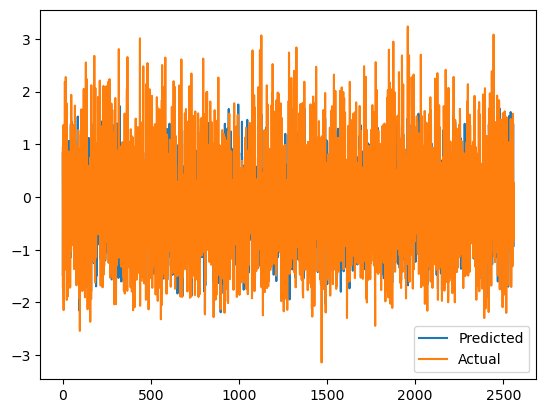

In [ ]:
batches_considered = 20

preds_train = np.array([])
targets_train = np.array([])
for v in traing[:batches_considered]:
    preds_train = np.append(preds_train, model.predict(v[0]))
    targets_train = np.append(targets_train, v[1])

plt.plot(preds_train, label="Predicted")
plt.plot(targets_train, label="Actual")

plt.legend()
plt.show()